# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**24012412**  
第5天专题：**A 用户生命周期**

本Notebook完成4张独立图、1张综合图和1份图表清单。

## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MaxNLocator
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012412"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

BG = "#F7F9FC"
TEXT = "#243447"
MUTED = "#66788A"
GRID = "#DDE5ED"
RETAINED = "#2A9D8F"
CHURNED = "#E76F51"
CHURNED_DARK = "#C84D37"
CHURNED_LIGHT = "#F8D7CB"
ACCENT = "#456990"


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


def style_axis(ax, ygrid=True):
    ax.set_facecolor(BG)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#B9C5D1")
    ax.tick_params(colors=MUTED, labelsize=10, length=0)
    if ygrid:
        ax.grid(axis="y", color=GRID, linewidth=0.9, alpha=0.8)
        ax.set_axisbelow(True)


def set_heading(ax, title, subtitle):
    ax.set_title(title, loc="left", fontsize=16, fontweight="bold", color=TEXT, pad=25)
    ax.text(0, 1.025, subtitle, transform=ax.transAxes, fontsize=10.5, color=MUTED, va="bottom")


def gradient_bars(ax, bars, bottom_color=CHURNED_DARK, top_color=CHURNED_LIGHT):
    cmap = LinearSegmentedColormap.from_list("bar_gradient", [bottom_color, top_color])
    gradient = np.linspace(0, 1, 256).reshape(256, 1)
    for bar in bars:
        x, y = bar.get_x(), bar.get_y()
        w, h = bar.get_width(), bar.get_height()
        bar.set_facecolor((0, 0, 0, 0))
        bar.set_edgecolor("#D65F45")
        bar.set_linewidth(0.7)
        bar.set_zorder(4)
        if h <= 0:
            continue
        image = ax.imshow(gradient, extent=[x, x + w, y, y + h], origin="lower", aspect="auto", cmap=cmap, zorder=3)
        image.set_clip_path(bar)


def gradient_area(ax, x, y, color=CHURNED):
    rgb = np.array(to_rgb(color))
    rgba = np.ones((256, 1, 4))
    rgba[:, :, :3] = rgb
    rgba[:, :, 3] = np.linspace(0.02, 0.28, 256).reshape(256, 1)
    vertices = [(x[0], 0), *list(zip(x, y)), (x[-1], 0), (x[0], 0)]
    codes = [MplPath.MOVETO] + [MplPath.LINETO] * (len(vertices) - 2) + [MplPath.CLOSEPOLY]
    patch = PathPatch(MplPath(vertices, codes), facecolor="none", edgecolor="none")
    ax.add_patch(patch)
    image = ax.imshow(rgba, extent=[x[0], x[-1], 0, max(y) * 1.08], origin="lower", aspect="auto", zorder=1)
    image.set_clip_path(patch)


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))

学生： 24012412
专题： A
输出： output/day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape == (5630, 22), f"清洗数据形状异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()) == {0, 1}
assert df[["CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"]].isna().sum().sum() == 0

display(overall_metrics)
display(segment_analysis)
display(cross_analysis.head())
df["ChurnLabel"] = df["Churn"].map({0: "未流失", 1: "已流失"})
print("检查点1A通过：输入文件有效")

,指标,数值
0,总用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现金额,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数,平均返现,用户占比
0,0-3个月,1560,653,0.42,2.32,155.66,0.28
1,4-6个月,590,44,0.07,2.97,169.91,0.10
2,7-12个月,1584,156,0.10,2.75,163.31,0.28
3,13-24个月,1467,95,0.06,3.70,204.92,0.26
4,25个月及以上,429,0,0.00,3.55,222.34,0.08


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-3个月,1,522,345,0.66,2.55,可观察
1,0-3个月,0,1038,308,0.30,2.20,可观察
2,4-6个月,1,137,30,0.22,3.03,可观察
3,7-12个月,1,406,81,0.20,2.67,可观察
4,13-24个月,1,414,52,0.13,3.35,可观察


检查点1A通过：输入文件有效


In [3]:
business_questions = {
    "category_bar": "不同用户任期阶段的流失率是否存在明显差异？",
    "behavior_scatter": "用户订单次数与返现金额呈现怎样的关系，流失用户与未流失用户是否形成不同分布？",
    "ordered_line": "流失率如何随用户任期阶段的有序推进而变化？",
    "composition_chart": "全部用户由流失与未流失两类用户按何种比例构成？",
}

chart_reasons = {
    "category_bar": "任期阶段是离散类别，需要准确比较各组流失率，因此使用带样本量标签的柱状图。",
    "behavior_scatter": "订单次数和返现金额均为用户级数值变量，散点图适合展示两者关系、重叠和离群情况。",
    "ordered_line": "任期阶段具有明确业务顺序，折线图用于展示相邻阶段之间的变化，但不将其解释为时间序列。",
    "composition_chart": "流失状态只有两个互斥类别且合计为全部用户，环形图适合展示整体构成。",
}

assert all(text.strip() for text in business_questions.values())
assert all(text.strip() for text in chart_reasons.values())
display(pd.DataFrame({"业务问题": business_questions, "选择理由": chart_reasons}))
print("检查点1B通过：业务问题和选择理由已填写")

,业务问题,选择理由
category_bar,不同用户任期阶段的流失率是否存在明显差异？,任期阶段是离散类别，需要准确比较各组流失率，因此使用带样本量标签的柱状图。
behavior_scatter,用户订单次数与返现金额呈现怎样的关系，流失用户与未流失用户是否形成不同分布？,订单次数和返现金额均为用户级数值变量，散点图适合展示两者关系、重叠和离群情况。
ordered_line,流失率如何随用户任期阶段的有序推进而变化？,任期阶段具有明确业务顺序，折线图用于展示相邻阶段之间的变化，但不将其解释为时间序列。
composition_chart,全部用户由流失与未流失两类用户按何种比例构成？,流失状态只有两个互斥类别且合计为全部用户，环形图适合展示整体构成。


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]
category_field = "TenureGroup"
df[category_field] = pd.cut(
    df["Tenure"],
    bins=[-0.001, 0, 6, 12, 24, np.inf],
    labels=TENURE_ORDER,
    ordered=True,
)
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失人数=("Churn", "sum"), 流失率=("Churn", "mean"))
      .reset_index()
      .sort_values(category_field)
      .reset_index(drop=True)
)
assert category_field in df.columns
assert list(category_summary[category_field].astype(str)) == TENURE_ORDER
assert isinstance(category_summary, pd.DataFrame)
assert {category_field, "用户数", "流失率"}.issubset(category_summary.columns)
display(category_summary)

,TenureGroup,用户数,流失人数,流失率
0,新用户,508,272,0.54
1,0-6个月,1642,425,0.26
2,7-12个月,1584,156,0.10
3,13-24个月,1467,95,0.06
4,24个月以上,429,0,0.00


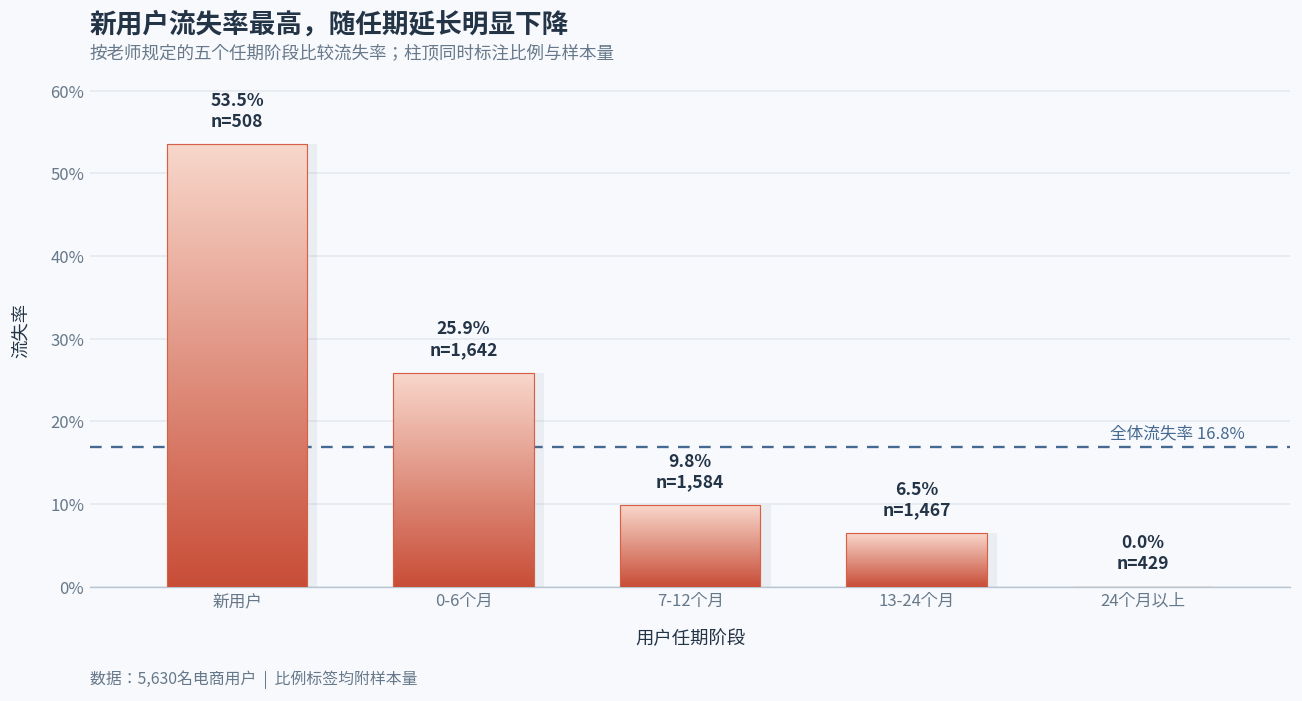

已输出： output/day06_visualization/01_category_bar.png


In [5]:
fig_bar, ax_bar = plt.subplots(figsize=(11.5, 7))
fig_bar.patch.set_facecolor(BG)
style_axis(ax_bar)

x = np.arange(len(category_summary))
rates = category_summary["流失率"].to_numpy()
shadow = ax_bar.bar(x + 0.045, rates, width=0.62, color="#7C8B99", alpha=0.10, linewidth=0, zorder=1)
bars = ax_bar.bar(x, rates, width=0.62, color=CHURNED, linewidth=0.7, zorder=3)
gradient_bars(ax_bar, bars)

overall_rate = df["Churn"].mean()
ax_bar.axhline(overall_rate, color=ACCENT, linewidth=1.4, linestyle=(0, (5, 4)), zorder=2)
ax_bar.text(len(x) - 0.55, overall_rate + 0.012, f"全体流失率 {overall_rate:.1%}", color=ACCENT, fontsize=10, ha="right")

for bar, rate, n in zip(bars, rates, category_summary["用户数"]):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, rate + 0.017, f"{rate:.1%}\nn={int(n):,}", ha="center", va="bottom", fontsize=10.5, color=TEXT, fontweight="bold")

set_heading(ax_bar, "新用户流失率最高，随任期延长明显下降", "按老师规定的五个任期阶段比较流失率；柱顶同时标注比例与样本量")
ax_bar.set_xticks(x, category_summary[category_field].astype(str))
ax_bar.set_xlabel("用户任期阶段", fontsize=11, color=TEXT, labelpad=12)
ax_bar.set_ylabel("流失率", fontsize=11, color=TEXT, labelpad=12)
ax_bar.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_bar.set_ylim(0, 0.62)
ax_bar.set_xlim(-0.65, len(x) - 0.35)
ax_bar.text(0, -0.19, "数据：5,630名电商用户  |  比例标签均附样本量", transform=ax_bar.transAxes, fontsize=9.5, color=MUTED)
fig_bar.subplots_adjust(left=0.10, right=0.97, top=0.82, bottom=0.21)

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, bbox_inches="tight", facecolor=fig_bar.get_facecolor())
plt.show()
plt.close(fig_bar)

assert bar_path.exists() and bar_path.stat().st_size > 5_000
print("已输出：", bar_path.relative_to(ROOT))

### 柱状图结论

- 观察：新用户的流失率最高，随着用户任期延长，各阶段流失率整体下降。
- 证据：新用户流失率为53.5%（n=508），0—6个月组为25.9%（n=1,642），13—24个月组为6.5%（n=1,467）；新用户与13—24个月组相差47.1个百分点，24个月以上组为0.0%（n=429）。
- 边界：该图展示分组关联，不能证明任期本身导致流失；24个月以上用户流失率为0还需要结合标签定义和观察窗口核查。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


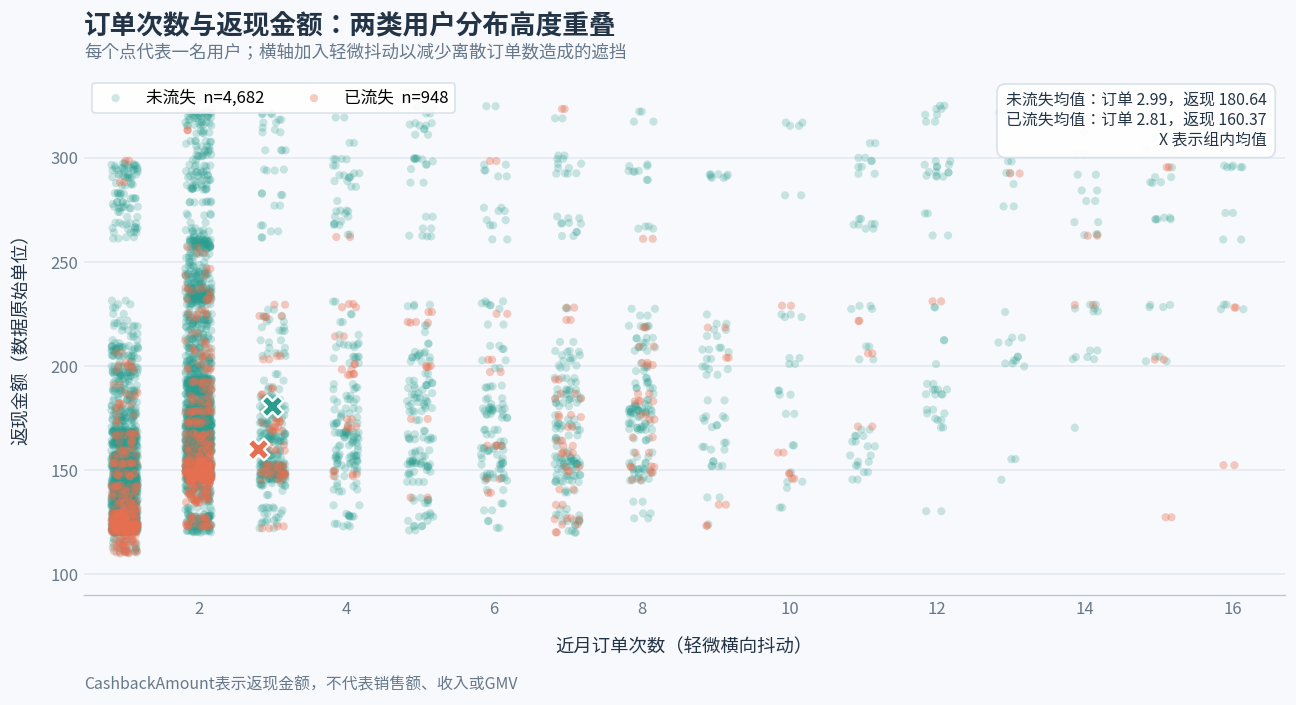

已输出： output/day06_visualization/02_behavior_scatter.png


In [6]:
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(11.5, 7))
fig_scatter.patch.set_facecolor(BG)
style_axis(ax_scatter)

rng = np.random.default_rng(2026)
colors = {0: RETAINED, 1: CHURNED}
labels = {0: "未流失", 1: "已流失"}
for churn_value in [0, 1]:
    part = df[df["Churn"] == churn_value]
    jittered_x = part[x_field].to_numpy() + rng.uniform(-0.18, 0.18, len(part))
    ax_scatter.scatter(jittered_x, part[y_field], s=24, alpha=0.24 if churn_value == 0 else 0.36, color=colors[churn_value], edgecolors="none", label=f"{labels[churn_value]}  n={len(part):,}", rasterized=True, zorder=2 + churn_value)

stats = df.groupby("Churn").agg(订单均值=("OrderCount", "mean"), 返现均值=("CashbackAmount", "mean"))
for churn_value in [0, 1]:
    ax_scatter.scatter(stats.loc[churn_value, "订单均值"], stats.loc[churn_value, "返现均值"], s=170, marker="X", color=colors[churn_value], edgecolor="white", linewidth=1.4, zorder=5)

set_heading(ax_scatter, "订单次数与返现金额：两类用户分布高度重叠", "每个点代表一名用户；横轴加入轻微抖动以减少离散订单数造成的遮挡")
ax_scatter.set_xlabel("近月订单次数（轻微横向抖动）", fontsize=11, color=TEXT, labelpad=12)
ax_scatter.set_ylabel("返现金额（数据原始单位）", fontsize=11, color=TEXT, labelpad=12)
ax_scatter.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=9))
ax_scatter.set_xlim(0.45, df[x_field].max() + 0.7)
ax_scatter.set_ylim(90, df[y_field].max() + 15)
legend = ax_scatter.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="#D7E0E8", fontsize=10, ncol=2)
legend.get_frame().set_alpha(0.92)
ax_scatter.text(0.985, 0.965, f"未流失均值：订单 {stats.loc[0, '订单均值']:.2f}，返现 {stats.loc[0, '返现均值']:.2f}\n已流失均值：订单 {stats.loc[1, '订单均值']:.2f}，返现 {stats.loc[1, '返现均值']:.2f}\nX 表示组内均值", transform=ax_scatter.transAxes, ha="right", va="top", fontsize=9.5, color=TEXT, bbox=dict(boxstyle="round,pad=0.55", facecolor="white", edgecolor="#D7E0E8", alpha=0.94))
ax_scatter.text(0, -0.18, "CashbackAmount表示返现金额，不代表销售额、收入或GMV", transform=ax_scatter.transAxes, fontsize=9.5, color=MUTED)
fig_scatter.subplots_adjust(left=0.10, right=0.97, top=0.82, bottom=0.20)

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, bbox_inches="tight", facecolor=fig_scatter.get_facecolor())
plt.show()
plt.close(fig_scatter)

assert scatter_path.exists() and scatter_path.stat().st_size > 5_000
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：订单次数与返现金额总体呈弱到中等程度的正向关系，但流失与未流失用户的点云高度重叠。
- 证据：两变量总体相关系数约为0.32；未流失用户平均订单数为2.99、平均返现为180.64，已流失用户分别为2.81和160.37。
- 边界：点云重叠说明仅凭这两个变量难以区分流失状态；轻微横向抖动只为减少遮挡，不改变原始订单数；相关关系不等于因果关系。

## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]
ordered_field = "TenureGroup"
ordered_summary = category_summary[["TenureGroup", "用户数", "流失人数", "流失率"]].copy()
ordered_summary[ordered_field] = pd.Categorical(ordered_summary[ordered_field], categories=TENURE_ORDER, ordered=True)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}
assert list(ordered_summary[ordered_field].astype(str)) == TENURE_ORDER
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数", "流失率"}.issubset(ordered_summary.columns)
display(ordered_summary)

,TenureGroup,用户数,流失人数,流失率
0,新用户,508,272,0.54
1,0-6个月,1642,425,0.26
2,7-12个月,1584,156,0.10
3,13-24个月,1467,95,0.06
4,24个月以上,429,0,0.00


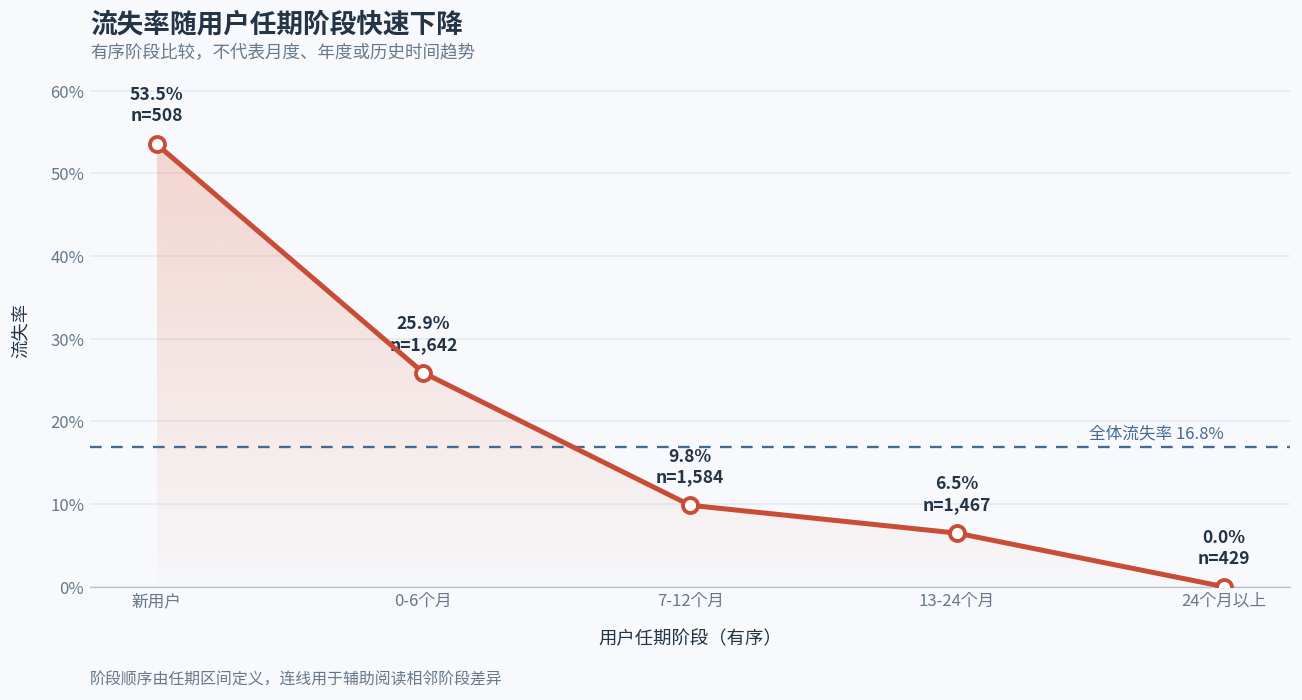

已输出： output/day06_visualization/03_ordered_line.png


In [8]:
fig_line, ax_line = plt.subplots(figsize=(11.5, 7))
fig_line.patch.set_facecolor(BG)
style_axis(ax_line)

x_line = np.arange(len(ordered_summary), dtype=float)
y_line = ordered_summary["流失率"].to_numpy()
gradient_area(ax_line, x_line, y_line)
ax_line.plot(x_line, y_line, color=CHURNED_DARK, linewidth=3.0, marker="o", markersize=9, markerfacecolor="white", markeredgecolor=CHURNED_DARK, markeredgewidth=2.3, zorder=4)
ax_line.axhline(df["Churn"].mean(), color=ACCENT, linewidth=1.4, linestyle=(0, (5, 4)), zorder=2)
ax_line.text(x_line[-1], df["Churn"].mean() + 0.012, f"全体流失率 {df['Churn'].mean():.1%}", color=ACCENT, fontsize=10, ha="right")

for xi, yi, n in zip(x_line, y_line, ordered_summary["用户数"]):
    ax_line.annotate(f"{yi:.1%}\nn={int(n):,}", (xi, yi), xytext=(0, 14), textcoords="offset points", ha="center", fontsize=10.5, color=TEXT, fontweight="bold")

set_heading(ax_line, "流失率随用户任期阶段快速下降", "有序阶段比较，不代表月度、年度或历史时间趋势")
ax_line.set_xticks(x_line, ordered_summary[ordered_field].astype(str))
ax_line.set_xlabel("用户任期阶段（有序）", fontsize=11, color=TEXT, labelpad=12)
ax_line.set_ylabel("流失率", fontsize=11, color=TEXT, labelpad=12)
ax_line.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_line.set_xlim(-0.25, len(x_line) - 0.75)
ax_line.set_ylim(0, 0.62)
ax_line.text(0, -0.19, "阶段顺序由任期区间定义，连线用于辅助阅读相邻阶段差异", transform=ax_line.transAxes, fontsize=9.5, color=MUTED)
fig_line.subplots_adjust(left=0.10, right=0.97, top=0.82, bottom=0.21)

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, bbox_inches="tight", facecolor=fig_line.get_facecolor())
plt.show()
plt.close(fig_line)

assert line_path.exists() and line_path.stat().st_size > 5_000
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：流失率从新用户阶段开始持续下降，任期越长的阶段总体流失率越低。
- 证据：流失率由新用户的53.5%（n=508）降至0—6个月的25.9%（n=1,642），下降27.7个百分点；之后依次降至7—12个月的9.8%、13—24个月的6.5%和24个月以上的0.0%。
- 边界：这是不同用户任期组之间的横截面有序比较，不是同一批用户随时间变化的纵向趋势。

## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
composition_field = "ChurnLabel"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
composition_summary[composition_field] = pd.Categorical(composition_summary[composition_field], categories=["未流失", "已流失"], ordered=True)
composition_summary = composition_summary.sort_values(composition_field).reset_index(drop=True)

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0)
display(composition_summary)

,ChurnLabel,用户数,占比
0,未流失,4682,0.83
1,已流失,948,0.17


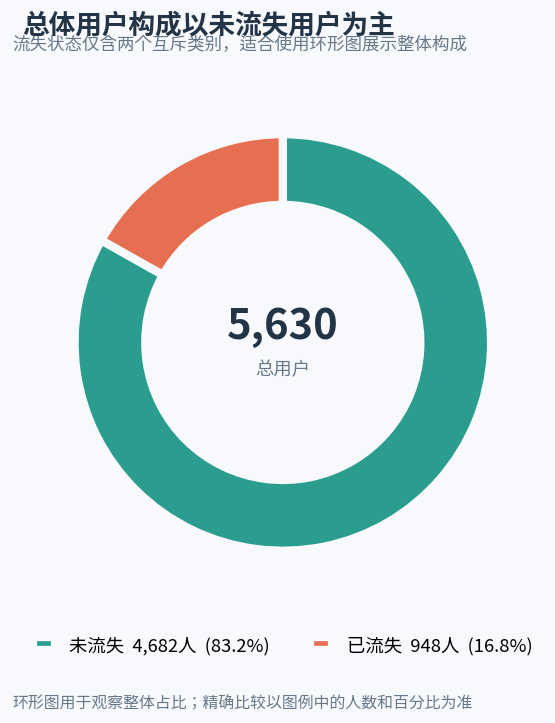

已输出： output/day06_visualization/04_composition_chart.png


In [10]:
fig_composition, ax_composition = plt.subplots(figsize=(10.5, 7))
fig_composition.patch.set_facecolor(BG)
ax_composition.set_facecolor(BG)

sizes = composition_summary["用户数"].to_numpy()
labels_comp = composition_summary[composition_field].astype(str).tolist()
colors_comp = [RETAINED, CHURNED]
wedges, _ = ax_composition.pie(sizes, startangle=90, counterclock=False, colors=colors_comp, wedgeprops=dict(width=0.34, edgecolor=BG, linewidth=5))
ax_composition.text(0, 0.08, f"{sizes.sum():,}", ha="center", va="center", fontsize=25, fontweight="bold", color=TEXT)
ax_composition.text(0, -0.13, "总用户", ha="center", va="center", fontsize=11, color=MUTED)
legend_labels = [f"{name}  {count:,}人  ({count / sizes.sum():.1%})" for name, count in zip(labels_comp, sizes)]
legend = ax_composition.legend(wedges, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.13), ncol=2, frameon=False, fontsize=11, handlelength=1.2, columnspacing=2.2)
ax_composition.set_title("总体用户构成以未流失用户为主", loc="left", fontsize=16, fontweight="bold", color=TEXT, pad=30)
ax_composition.text(-0.02, 1.055, "流失状态仅含两个互斥类别，适合使用环形图展示整体构成", transform=ax_composition.transAxes, fontsize=10.5, color=MUTED, va="bottom")
ax_composition.text(-0.02, -0.20, "环形图用于观察整体占比；精确比较以图例中的人数和百分比为准", transform=ax_composition.transAxes, fontsize=9.5, color=MUTED)
ax_composition.set_aspect("equal")
fig_composition.subplots_adjust(left=0.08, right=0.96, top=0.82, bottom=0.20)

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, bbox_inches="tight", facecolor=fig_composition.get_facecolor())
plt.show()
plt.close(fig_composition)

assert composition_path.exists() and composition_path.stat().st_size > 5_000
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：样本中未流失用户占绝大多数，流失用户约占六分之一。
- 证据：未流失用户4,682人，占83.2%；流失用户948人，占16.8%。
- 边界：环形图只展示整体构成，不能说明哪些特征与流失有关，也不适合比较多个接近比例的细分类别。

## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


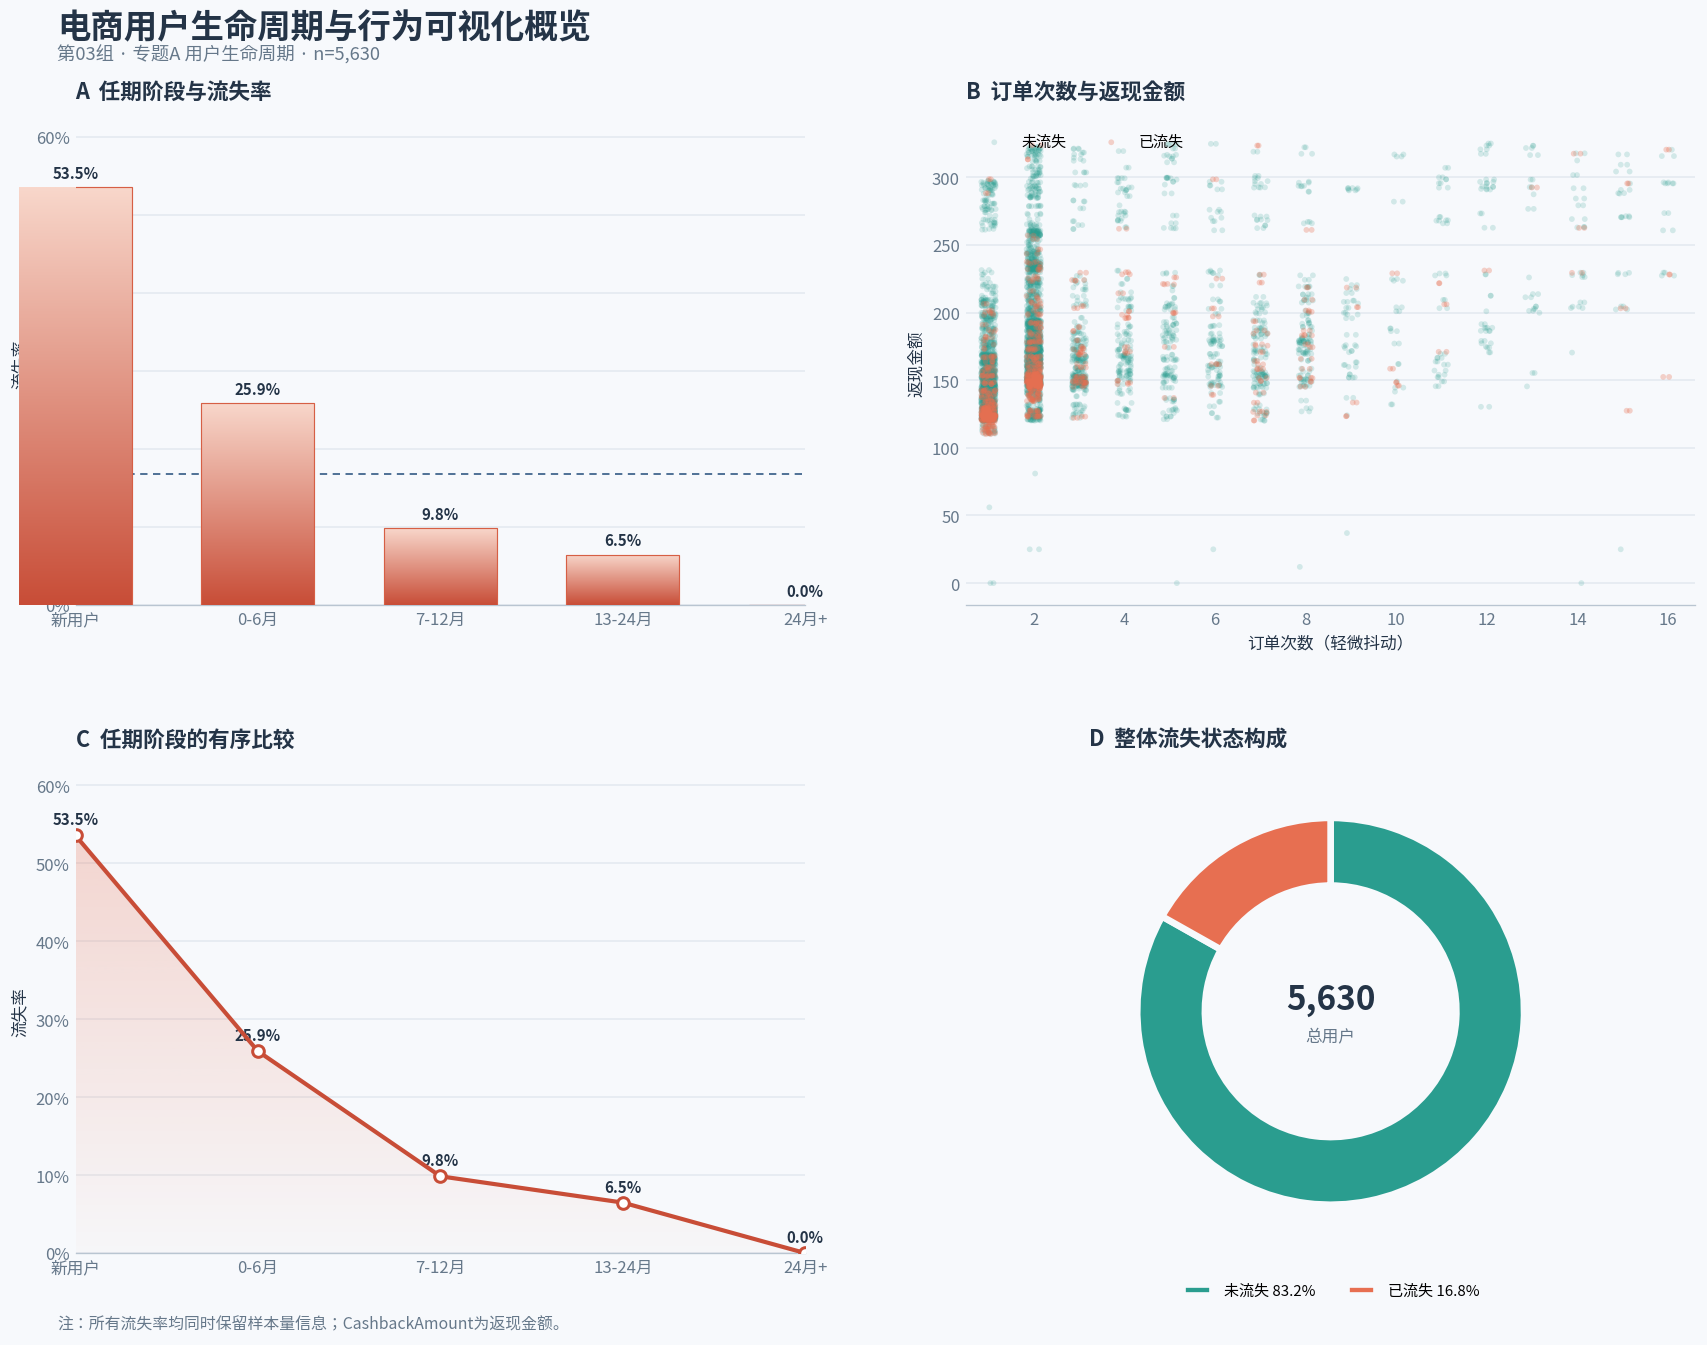

已输出： output/day06_visualization/day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(15, 11.5))
fig_summary.patch.set_facecolor(BG)

ax = axes[0, 0]
style_axis(ax)
bars_s = ax.bar(np.arange(len(category_summary)), category_summary["流失率"], width=0.62, color=CHURNED, zorder=3)
gradient_bars(ax, bars_s)
ax.axhline(df["Churn"].mean(), color=ACCENT, linewidth=1.1, linestyle=(0, (4, 3)))
for bar, rate in zip(bars_s, category_summary["流失率"]):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.012, f"{rate:.1%}", ha="center", fontsize=9, color=TEXT, fontweight="bold")
ax.set_xticks(np.arange(len(category_summary)), ["新用户", "0-6月", "7-12月", "13-24月", "24月+"])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 0.62)
ax.set_title("A  任期阶段与流失率", loc="left", fontsize=13, fontweight="bold", color=TEXT, pad=14)
ax.set_ylabel("流失率", color=TEXT)

ax = axes[0, 1]
style_axis(ax)
rng_summary = np.random.default_rng(2026)
for churn_value in [0, 1]:
    part = df[df["Churn"] == churn_value]
    ax.scatter(part["OrderCount"].to_numpy() + rng_summary.uniform(-0.16, 0.16, len(part)), part["CashbackAmount"], s=12, alpha=0.18 if churn_value == 0 else 0.30, color=colors[churn_value], edgecolors="none", label=labels[churn_value], rasterized=True)
ax.set_title("B  订单次数与返现金额", loc="left", fontsize=13, fontweight="bold", color=TEXT, pad=14)
ax.set_xlabel("订单次数（轻微抖动）", color=TEXT)
ax.set_ylabel("返现金额", color=TEXT)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left")
ax.set_xlim(0.5, df["OrderCount"].max() + 0.6)

ax = axes[1, 0]
style_axis(ax)
gradient_area(ax, x_line, y_line)
ax.plot(x_line, y_line, color=CHURNED_DARK, linewidth=2.5, marker="o", markersize=7, markerfacecolor="white", markeredgecolor=CHURNED_DARK, markeredgewidth=1.8, zorder=4)
for xi, yi in zip(x_line, y_line):
    ax.text(xi, yi + 0.014, f"{yi:.1%}", ha="center", fontsize=9, color=TEXT, fontweight="bold")
ax.set_xticks(x_line, ["新用户", "0-6月", "7-12月", "13-24月", "24月+"])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 0.62)
ax.set_title("C  任期阶段的有序比较", loc="left", fontsize=13, fontweight="bold", color=TEXT, pad=14)
ax.set_ylabel("流失率", color=TEXT)

ax = axes[1, 1]
ax.set_facecolor(BG)
wedges_s, _ = ax.pie(sizes, startangle=90, counterclock=False, colors=colors_comp, wedgeprops=dict(width=0.35, edgecolor=BG, linewidth=4))
ax.text(0, 0.06, f"{sizes.sum():,}", ha="center", va="center", fontsize=20, fontweight="bold", color=TEXT)
ax.text(0, -0.13, "总用户", ha="center", va="center", fontsize=10, color=MUTED)
ax.legend(wedges_s, [f"未流失 {sizes[0] / sizes.sum():.1%}", f"已流失 {sizes[1] / sizes.sum():.1%}"], loc="lower center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=9)
ax.set_title("D  整体流失状态构成", loc="left", fontsize=13, fontweight="bold", color=TEXT, pad=14)
ax.set_aspect("equal")

fig_summary.suptitle("电商用户生命周期与行为可视化概览", fontsize=20, fontweight="bold", color=TEXT, x=0.06, ha="left", y=0.98)
fig_summary.text(0.06, 0.945, "第03组 · 专题A 用户生命周期 · n=5,630", fontsize=11, color=MUTED)
fig_summary.text(0.06, 0.025, "注：所有流失率均同时保留样本量信息；CashbackAmount为返现金额。", fontsize=9.5, color=MUTED)
fig_summary.subplots_adjust(left=0.07, right=0.97, top=0.90, bottom=0.08, hspace=0.34, wspace=0.22)

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, bbox_inches="tight", facecolor=fig_summary.get_facecolor())
plt.show()
plt.close(fig_summary)

assert summary_path.exists() and summary_path.stat().st_size > 5_000
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：生命周期最早阶段的流失风险最突出。新用户流失率为53.5%（n=508），明显高于总体流失率16.8%；0—6个月组流失率仍达到25.9%（n=1,642）。
2. 综合发现2：总体样本中流失用户948人，占16.8%；未流失用户4,682人，占83.2%，类别构成明显不均衡。
3. 综合发现3：订单次数与返现金额存在一定正向关系，但两类用户分布高度重叠；已流失用户平均返现160.37，低于未流失用户的180.64。
4. 数据或方法局限：本分析使用横截面数据，只能描述关联；24个月以上用户流失率为0可能受到标签定义或观察窗口影响，需要结合原始业务规则进一步核查。

`CashbackAmount`是返现金额，不是销售额、收入或GMV。

## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": business_questions["category_bar"], "chart_type": "bar", "key_finding": "新用户流失率53.5%，0-6个月组为25.9%，均高于总体16.8%。", "limitation": "分组关联不能证明任期导致流失，24个月以上组0流失率需核查标签与观察窗口。"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": business_questions["behavior_scatter"], "chart_type": "scatter", "key_finding": "订单次数与返现金额总体相关系数约0.32，但流失与未流失点云高度重叠。", "limitation": "轻微横向抖动仅用于减少遮挡，两个变量不足以单独区分流失状态。"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": business_questions["ordered_line"], "chart_type": "line", "key_finding": "流失率由新用户的53.5%逐步降至24个月以上的0.0%。", "limitation": "任期阶段是有序横截面分组，不是同一批用户的时间趋势。"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": business_questions["composition_chart"], "chart_type": "donut", "key_finding": "未流失用户4,682人占83.2%，流失用户948人占16.8%。", "limitation": "整体构成不能解释具体流失驱动因素。"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "用户生命周期、行为关系和整体流失构成呈现出哪些共同特征？", "chart_type": "dashboard", "key_finding": "高流失主要集中在新用户和0-6个月阶段，行为变量有均值差异但用户分布仍高度重叠。", "limitation": "综合图用于概览，精确数值和结论边界需结合独立图与原始数据阅读。"},
])

assert len(chart_manifest) == 5
assert chart_manifest.notna().all().all()
assert chart_manifest.astype(str).apply(lambda col: col.str.strip().ne("").all()).all()

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同用户任期阶段的流失率是否存在明显差异？,bar,新用户流失率53.5%，0-6个月组为25.9%，均高于总体16.8%。,分组关联不能证明任期导致流失，24个月以上组0流失率需核查标签与观察窗口。
1,02,02_behavior_scatter.png,用户订单次数与返现金额呈现怎样的关系，流失用户与未流失用户是否形成不同分布？,scatter,订单次数与返现金额总体相关系数约0.32，但流失与未流失点云高度重叠。,轻微横向抖动仅用于减少遮挡，两个变量不足以单独区分流失状态。
2,03,03_ordered_line.png,流失率如何随用户任期阶段的有序推进而变化？,line,流失率由新用户的53.5%逐步降至24个月以上的0.0%。,任期阶段是有序横截面分组，不是同一批用户的时间趋势。
3,04,04_composition_chart.png,全部用户由流失与未流失两类用户按何种比例构成？,donut,"未流失用户4,682人占83.2%，流失用户948人占16.8%。",整体构成不能解释具体流失驱动因素。
4,05,day06_visualization_summary.png,用户生命周期、行为关系和整体流失构成呈现出哪些共同特征？,dashboard,高流失主要集中在新用户和0-6个月阶段，行为变量有均值差异但用户分布仍高度重叠。,综合图用于概览，精确数值和结论边界需结合独立图与原始数据阅读。


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
